# PHEMS Pediatric Sepsis — Data Exploration

Goal: get a clear picture of the data before deciding on features or models.

**The task:** at every (patient, hour) row in the test set, predict the probability that the patient currently has sepsis. The submission key is `person_id_datetime` (e.g. `1416048048_2021-03-25 10:00:00`) and the value is a float probability.

Sections:
1. Foundations — sizes, patients, class balance, demographics
2. Temporal structure — stay lengths, when sepsis turns positive, lead time
3. Per-table content — what features exist, missingness, value distributions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

ROOT = Path('phems-hackathon-early-sepsis-prediction')
TRAIN = ROOT / 'training_data'
TEST = ROOT / 'testing_data'

Matplotlib is building the font cache; this may take a moment.


## 1. Foundations

Load the labels and demographics, get the basic shape of the problem.

In [3]:
y_train = pd.read_csv(TRAIN / 'SepsisLabel_train.csv')
y_test = pd.read_csv(TEST / 'SepsisLabel_test.csv')
sub_sample = pd.read_csv(ROOT / 'SepsisLabel_sample_submission.csv')

y_train['measurement_datetime'] = pd.to_datetime(y_train['measurement_datetime'])
y_test['measurement_datetime'] = pd.to_datetime(y_test['measurement_datetime'])

print('Train labels:', y_train.shape)
print('Test rows:   ', y_test.shape)
print('Submission:  ', sub_sample.shape)
y_train.head()

Train labels: (331653, 3)
Test rows:    (130483, 2)
Submission:   (130483, 2)


,person_id,measurement_datetime,SepsisLabel
0,274096387,2024-12-03 20:00:00,0
1,1719359031,2024-04-20 09:00:00,0
2,2024544816,2021-07-14 07:00:00,0
3,213710896,2022-05-24 07:00:00,0
4,1335786468,2024-08-25 22:00:00,0


In [4]:
# Confirm the submission format we have to produce
print('Sample submission columns:', sub_sample.columns.tolist())
print('Sample submission rows:   ', len(sub_sample))
print('Sample value distribution:', sub_sample['SepsisLabel'].value_counts().head())
print()
print('First 3 keys:')
print(sub_sample.head(3).to_string(index=False))

Sample submission columns: ['person_id_datetime', 'SepsisLabel']
Sample submission rows:    130483
Sample value distribution: SepsisLabel
0.5    130483
Name: count, dtype: int64

First 3 keys:
            person_id_datetime  SepsisLabel
1416048048_2021-03-25 10:00:00          0.5
 280531880_2024-01-22 18:00:00          0.5
1127023302_2023-12-29 21:00:00          0.5


In [5]:
# Class balance — both at the (person, hour) level and at the patient level
hour_pos = y_train['SepsisLabel'].mean()
patient_max = y_train.groupby('person_id')['SepsisLabel'].max()
patient_pos = patient_max.mean()

print(f'Hour-level positive rate:    {hour_pos:.4f}  ({y_train.SepsisLabel.sum():,} / {len(y_train):,})')
print(f'Patient-level positive rate: {patient_pos:.4f}  ({patient_max.sum():.0f} / {patient_max.size:,})')
print()
print('This is a SEVERELY imbalanced problem at the hour level.')
print('Class weighting / SMOTE / threshold tuning will matter.')

Hour-level positive rate:    0.0207  (6,874 / 331,653)
Patient-level positive rate: 0.0366  (97 / 2,649)

This is a SEVERELY imbalanced problem at the hour level.
Class weighting / SMOTE / threshold tuning will matter.


In [6]:
print(f'Unique train patients: {y_train.person_id.nunique():,}')
print(f'Unique test patients:  {y_test.person_id.nunique():,}')
print(f'Patient overlap:       {len(set(y_train.person_id) & set(y_test.person_id))}')
print()
print('No patient overlap means we can split train however we want without leakage')
print('between train/val patients.')

Unique train patients: 2,649
Unique test patients:  1,138
Patient overlap:       18

No patient overlap means we can split train however we want without leakage
between train/val patients.


In [7]:
demo_tr = pd.read_csv(TRAIN / 'person_demographics_episode_train.csv')
demo_te = pd.read_csv(TEST / 'person_demographics_episode_test.csv')

print(f'Demographics rows (train): {len(demo_tr):,}')
print(f'Unique persons in demo:    {demo_tr.person_id.nunique():,}')
print(f'  -> implies multiple visits per patient (visit-level rows)')
print()
print('Gender (train):', demo_tr.gender.value_counts(dropna=False).to_dict())
print()
print('Age in months (train):')
print(demo_tr.age_in_months.describe().round(1))
print()
print(f'Age in years — median: {demo_tr.age_in_months.median()/12:.1f}y, max: {demo_tr.age_in_months.max()/12:.1f}y')

Demographics rows (train): 3,391
Unique persons in demo:    2,649
  -> implies multiple visits per patient (visit-level rows)

Gender (train): {'MALE': 1952, 'FEMALE': 1439}

Age in months (train):
count    3391.0
mean       69.2
std        69.5
min         0.0
25%         7.0
50%        43.0
75%       127.0
max       256.0
Name: age_in_months, dtype: float64

Age in years — median: 3.6y, max: 21.3y


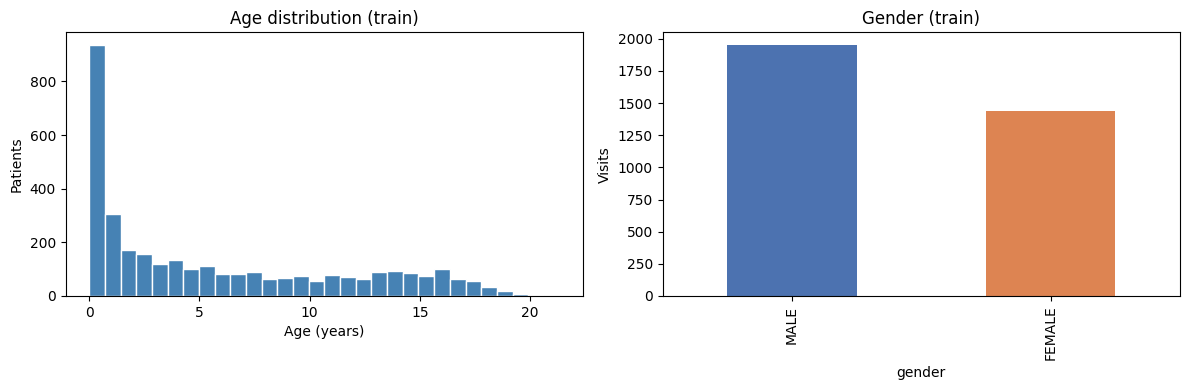

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(demo_tr.age_in_months / 12, bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('Patients'); axes[0].set_title('Age distribution (train)')
demo_tr.gender.value_counts().plot.bar(ax=axes[1], color=['#4c72b0', '#dd8452'])
axes[1].set_title('Gender (train)'); axes[1].set_ylabel('Visits')
plt.tight_layout(); plt.show()

## 2. Temporal structure

How long are the stays, when do positive labels appear, and how much lead time exists before sepsis onset?

In [9]:
hours_per_pt = y_train.groupby('person_id').size()
print('Hours per patient (train):')
print(hours_per_pt.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(1))
print()
print(f'Long tail: max stay is {hours_per_pt.max():,} hours = {hours_per_pt.max()/24:.0f} days')

Hours per patient (train):
count    2649.0
mean      125.2
std       265.8
min         1.0
25%        27.0
50%        55.0
75%       125.0
90%       269.0
95%       450.0
99%      1106.6
max      5792.0
dtype: float64

Long tail: max stay is 5,792 hours = 241 days


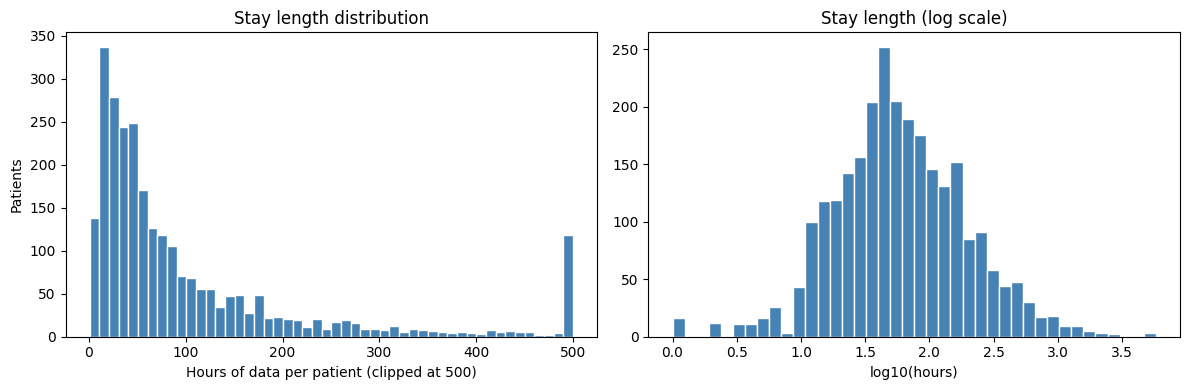

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(hours_per_pt.clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Hours of data per patient (clipped at 500)'); axes[0].set_ylabel('Patients')
axes[0].set_title('Stay length distribution')
axes[1].hist(np.log10(hours_per_pt), bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('log10(hours)'); axes[1].set_title('Stay length (log scale)')
plt.tight_layout(); plt.show()

In [11]:
# For patients who go septic, how many hours into their stay does the first positive label appear?
y_train_sorted = y_train.sort_values(['person_id', 'measurement_datetime'])
y_train_sorted['hour_index'] = y_train_sorted.groupby('person_id').cumcount()

septic_pts = y_train_sorted[y_train_sorted.SepsisLabel == 1].groupby('person_id').agg(
    first_pos_hour=('hour_index', 'min'),
    n_pos_hours=('hour_index', 'count'),
)
septic_pts['stay_length'] = hours_per_pt.loc[septic_pts.index].values
septic_pts['lead_time'] = septic_pts['first_pos_hour']
septic_pts['septic_fraction'] = septic_pts['n_pos_hours'] / septic_pts['stay_length']

print(f'Septic patients in train: {len(septic_pts)}')
print()
print('Hours of healthy data BEFORE first positive label (lead time):')
print(septic_pts['lead_time'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))
print()
print('Fraction of stay that is septic:')
print(septic_pts['septic_fraction'].describe(percentiles=[0.25, 0.5, 0.75]).round(3))

Septic patients in train: 97

Hours of healthy data BEFORE first positive label (lead time):
count      97.0
mean      106.9
std       188.5
min         0.0
10%         0.0
25%         6.0
50%        40.0
75%       116.0
90%       324.4
max      1416.0
Name: lead_time, dtype: float64

Fraction of stay that is septic:
count    97.000
mean      0.156
std       0.123
min       0.009
25%       0.066
50%       0.129
75%       0.204
max       0.649
Name: septic_fraction, dtype: float64


## 3. Per-table content & missingness

What features actually exist, how sparse are they, and what value ranges do they cover?

In [12]:
# Vitals are the most clinically-direct signal for sepsis. Look at them carefully.
vitals = pd.read_csv(TRAIN / 'measurement_meds_train.csv')
vitals['measurement_datetime'] = pd.to_datetime(vitals['measurement_datetime'])
print('Vitals shape:', vitals.shape)
print('Columns:', vitals.columns.tolist())
print()
vitals_cols = [c for c in vitals.columns if c not in ('visit_occurrence_id', 'person_id', 'measurement_datetime')]
print('Per-row missingness (fraction of NaN in this row):')
print(vitals[vitals_cols].describe().round(2))
print()
print(f'Unique patients with vitals: {vitals.person_id.nunique()}')
print(f'Vital records per patient — median: {int(vitals.groupby("person_id").size().median())}')

Vitals shape: (257749, 10)
Columns: ['visit_occurrence_id', 'person_id', 'measurement_datetime', 'Systolic blood pressure', 'Diastolic blood pressure', 'Body temperature', 'Respiratory rate', 'Heart rate', 'Measurement of oxygen saturation at periphery', 'Oxygen/Gas total [Pure volume fraction] Inhaled gas']

Per-row missingness (fraction of NaN in this row):
       Systolic blood pressure  Diastolic blood pressure  Body temperature  Respiratory rate  Heart rate  Measurement of oxygen saturation at periphery  \
count                 40095.00                  40082.00         204136.00          83304.00    96973.00                                       96817.00   
mean                    236.85                    133.97             37.87            478.17     1697.48                                        1246.62   
std                    3767.82                   2082.88            217.40           3995.04    13910.36                                       10468.13   
min               

In [13]:
labs = pd.read_csv(TRAIN / 'measurement_lab_train.csv')
labs['measurement_datetime'] = pd.to_datetime(labs['measurement_datetime'])
lab_cols = [c for c in labs.columns if c not in ('visit_occurrence_id', 'person_id', 'measurement_datetime')]
print(f'Lab table: {labs.shape}, {len(lab_cols)} lab measurements')
print()
print('Missingness rate per lab column (sorted):')
miss = labs[lab_cols].isna().mean().sort_values()
print(miss.round(3).to_string())

Lab table: (69307, 40), 37 lab measurements

Missingness rate per lab column (sorted):
Chloride [Moles/volume] in Blood                       0.523
Sodium [Moles/volume] in Serum or Plasma               0.524
Potassium [Moles/volume] in Blood                      0.536
Hematocrit [Volume Fraction] of Blood                  0.594
Blood arterial pH                                      0.604
Creatinine [Mass/volume] in Blood                      0.621
 activated                                             0.637
Total white blood count                                0.638
Hemoglobin [Moles/volume] in Blood                     0.638
Neutrophil Ab [Units/volume] in Serum                  0.639
C reactive protein [Mass/volume] in Serum or Plasma    0.664
White blood cell count                                 0.682
Bicarbonate [Moles/volume] in Venous blood             0.685
Oxygen [Partial pressure] in Venous blood              0.686
Lactate [Moles/volume] in Blood                        0.70

In [14]:
# Devices, procedures, drugs are 'event' tables — long format, one row per occurrence
devices = pd.read_csv(TRAIN / 'devices_train.csv')
procs = pd.read_csv(TRAIN / 'proceduresoccurrences_train.csv')
drugs = pd.read_csv(TRAIN / 'drugsexposure_train.csv')

print(f'devices:    {len(devices):,} rows, {devices.device.nunique()} unique device types')
print(f'procedures: {len(procs):,} rows, {procs.procedure.nunique()} unique procedures')
print(f'drugs:      {len(drugs):,} rows, {drugs.drug_concept_id.nunique()} unique drugs, {drugs.route_concept_id.nunique()} routes')
print()
print('Top 10 device types:')
print(devices.device.value_counts().head(10))
print()
print('Top 10 procedures:')
print(procs.procedure.value_counts().head(10))

devices:    750,878 rows, 5 unique device types
procedures: 771,214 rows, 7 unique procedures
drugs:      184,780 rows, 50 unique drugs, 9 routes

Top 10 device types:
device
Urinary catheter                      198542
Central venous catheter               188955
Arterial blood pressure catheter      173702
Nasogastric/orogastric tube stylet    169397
Endotracheal tube                      20282
Name: count, dtype: int64

Top 10 procedures:
procedure
Cannulation                            584235
Non-invasive ventilation               117261
Invasive ventilation                    35080
Exteriorization of trachea              32168
Peritoneal dialysis                      1477
Dialysis procedure                        925
Extracorporeal membrane oxygenation        68
Name: count, dtype: int64


In [15]:
# How well do the feature tables actually cover the prediction hours?
# i.e. for each label hour, how often do we have a row in each feature table?
from data_prep import to_hour

label_keys = y_train[['person_id', 'measurement_datetime']].copy()

def coverage(df, dt_col):
    df = df[['person_id', dt_col]].copy()
    df['measurement_datetime'] = to_hour(df[dt_col])
    keys = df[['person_id', 'measurement_datetime']].drop_duplicates()
    merged = label_keys.merge(keys.assign(_present=1), on=['person_id', 'measurement_datetime'], how='left')
    return merged['_present'].notna().mean()

print('Fraction of label hours covered by each table:')
print(f'  vitals (meds):    {coverage(vitals, "measurement_datetime"):.3f}')
print(f'  labs:             {coverage(labs, "measurement_datetime"):.3f}')
print(f'  devices:          {coverage(devices, "device_datetime_hourly"):.3f}')
print(f'  procedures:       {coverage(procs, "procedure_datetime_hourly"):.3f}')
print(f'  drugs:            {coverage(drugs, "drug_datetime_hourly"):.3f}')

Fraction of label hours covered by each table:
  vitals (meds):    0.755
  labs:             0.205
  devices:          0.551
  procedures:       0.590
  drugs:            0.200


## Summary of findings

Fill this in after running the cells above. Things to note:
- Class imbalance ratio and what it implies for evaluation
- Median stay length — informs window-based feature engineering
- Lead time — informs how early we can realistically predict
- Coverage — informs whether per-hour features will be mostly NaN
- Missingness rate per lab — informs which labs are usable as features